# LINCS Cell Painting morphology profile analysis: batch1 plate/replicate UMAP

This is the LINCS counterpart to `morphology_umap_analysis.ipynb` (which
analyzes the HepG2 bioactive-library screen across its 4 independent
production sites). Per the same scope as `lincs_morphology_expression_integration.ipynb`,
this notebook covers **only `2016_04_01_a549_48hr_batch1`** (A549, 48h, the
~1500-compound Drug Repurposing Hub library at up to 7 doses) - not the
second LINCS batch (`2017_12_05_Batch2`), which spans 3 cell lines x 3
timepoints x 3 compound libraries and isn't a like-for-like comparison.

**Why this isn't a literal site-for-site mirror of the HepG2 notebook.**
HepG2 had 4 independent sites each re-running the *identical* 7-plate
library end to end - a clean site x plate x replicate grid, so "does site
dominate the embedding" is a pure technical-batch-effect question. Batch1's
own internal structure, carried directly in `Metadata_Batch_Number` /
`Metadata_Batch_Date` and `Metadata_Plate_Map_Name`, is different: it's a
**primary screen plus confirmatory retest** design -

- `Batch_Number` 1 (2016-03-22) runs all 28 plate-map designs once each (28
  plates) - a single broad pass across the whole library.
- `Batch_Number`s 2-5 (2016-04-05 through 2016-05-30) each deepen a
  *disjoint* subset of ~7 of those 28 designs at 3-4 replicate plates - not
  a repeat of the whole library, so `Batch_Number` is confounded with *which
  compounds* rather than being an orthogonal technical replicate of
  everything, the way HepG2's sites were.

So instead of one "site effect" question, this notebook asks two more
specific ones: does plate-map/compound identity structure the embedding (a
real, expected effect given each design covers different compounds - the
`Metadata_Plate_Map_Name` analog of HepG2's `Metadata_PlateID`), and, for
designs that have both an early single-well (batch 1) and a later
replicate-mean (batch 2-5) measurement, do those two measurements of the
*same* compound-dose combination actually agree - the fair,
apples-to-apples reproducibility check this design supports, replacing
HepG2's site-vs-site comparison.

**Another simplification vs. HepG2.** Level 3's platemap join already
attaches compound identity, dose, and literature MoA directly
(`Metadata_pert_iname`, `Metadata_dose_recode`, `Metadata_moa`) - no
external annotation-file join is needed at all here, unlike HepG2's
`EOS` -> `pdid` bridge. The only annotated control is `DMSO`
(`Metadata_pert_type == "control"`); batch1 has no separate positive
control compound like HepG2's Nocodazole/Tetrandrine.


In [1]:
import glob
import os
from pathlib import Path
import warnings

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from pycytominer import feature_select, normalize
from pycytominer.cyto_utils import infer_cp_features
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

warnings.filterwarnings("ignore")
sc.settings.verbosity = 0
plt.rcParams["figure.facecolor"] = "#fcfcfb"
plt.rcParams["axes.facecolor"] = "#fcfcfb"
plt.rcParams["font.size"] = 10

RANDOM_STATE = 0
N_PCS = 50
# The kernel's cwd depends entirely on the launcher: JupyterLab starts in the
# notebook's OWN directory (LINCS/), papermill starts wherever it was invoked,
# and VS Code defaults to the WORKSPACE ROOT - which is the repo root, an
# ANCESTOR of LINCS/. Walking upward alone therefore cannot satisfy both, and
# from the repo root it walks to / and raises. Search cwd and every parent, and
# under each also the known stream subpaths. Override with WS4_STREAM_ROOT when
# the checkout lives elsewhere. Without a correct root, glob() silently returns
# [] and pd.concat raises "No objects to concatenate" several cells later.
_SUBPATHS = [
    Path("."),
    Path("2026_08_hackathon_cellpainting/ws4_multiomics/hackathon_crossmodal_stream"),
    Path("ws4_multiomics/hackathon_crossmodal_stream"),
    Path("hackathon_crossmodal_stream"),
]


def _find_stream_root() -> Path:
    seeds = []
    if os.environ.get("WS4_STREAM_ROOT"):
        seeds.append(Path(os.environ["WS4_STREAM_ROOT"]))
    nb = globals().get("__vsc_ipynb_file__")  # VS Code sets this; Jupyter does not
    if nb:
        seeds.append(Path(nb).resolve().parent)
    seeds.append(Path.cwd().resolve())
    for seed in seeds:
        for base in [seed, *seed.parents]:
            for sub in _SUBPATHS:
                if (base / sub / "LINCS" / "data" / "morphology").is_dir():
                    return (base / sub).resolve()
    raise FileNotFoundError(
        f"LINCS/data/morphology not found from cwd={Path.cwd()}. "
        "Set WS4_STREAM_ROOT to the hackathon_crossmodal_stream directory, "
        "or fetch the data - see docs/ws4/data.md."
    )


ROOT = _find_stream_root()
LINCS_DIR = str(ROOT / "LINCS" / "data")  # all LINCS data lives here
MORPH_DIR = f"{LINCS_DIR}/morphology"     # lincs-cell-painting checkout, 1.1 GB
BATCH1 = "2016_04_01_a549_48hr_batch1"
COMPARTMENTS = ["Cells", "Nuclei", "Cytoplasm"]
FEATURE_SELECT_OPS = ["variance_threshold", "correlation_threshold", "drop_na_columns", "blocklist"]

# Fixed-order categorical palette (validated for adjacent-pair colorblind
# safety), reused consistently across all categorical color encodings below -
# same palette as morphology_umap_analysis.ipynb.
PALETTE = [
    "#2a78d6",  # blue
    "#eb6834",  # orange
    "#1baf7a",  # aqua
    "#eda100",  # yellow
    "#e87ba4",  # magenta
    "#008300",  # green
    "#4a3aa7",  # violet
    "#e34948",  # red
]


## 1. Load raw Level 3 profiles (136 plates, pooled)

Level 3 (`_augmented.csv.gz`) already carries `Metadata_Plate`,
`Metadata_Plate_Map_Name`, `Metadata_Batch_Number`/`Metadata_Batch_Date`, and
compound/dose/MoA annotation per well from the platemap join baked in at
acquisition time - no filename parsing or separate annotation join needed
(contrast `morphology_umap_analysis.ipynb`'s regex-based plate/replicate
parsing and its EOS-annotation-file join).


In [2]:
def load_level3_plate(f):
    d = pd.read_csv(f)
    feat_cols = [c for c in d.columns if not c.startswith("Metadata_")]
    d = d.astype({c: "float32" for c in feat_cols})
    return d


level3_files = sorted(glob.glob(f"{MORPH_DIR}/profiles/{BATCH1}/*/*_augmented.csv.gz"))
print(f"batch1: {len(level3_files)} Level 3 plate files")

level3_batch1 = pd.concat([load_level3_plate(f) for f in level3_files], ignore_index=True)
CP_FEATURES = infer_cp_features(level3_batch1, compartments=COMPARTMENTS)
print(f"{level3_batch1.shape[0]} wells x {len(CP_FEATURES)} inferred CP features")

plate_design = (
    level3_batch1[["Metadata_Plate", "Metadata_Plate_Map_Name", "Metadata_Batch_Number", "Metadata_Batch_Date"]]
    .drop_duplicates()
)
print(f"{plate_design['Metadata_Plate_Map_Name'].nunique()} distinct plate-map designs, "
      f"{plate_design['Metadata_Batch_Number'].nunique()} distinct batch numbers")
pd.crosstab(plate_design["Metadata_Plate_Map_Name"], plate_design["Metadata_Batch_Number"])


batch1: 136 Level 3 plate files


52223 wells x 1781 inferred CP features
28 distinct plate-map designs, 5 distinct batch numbers


Metadata_Batch_Number,1,2,3,4,5
Metadata_Plate_Map_Name,,,,,
C-7161-01-LM6-001,1,4,0,0,0
C-7161-01-LM6-002,1,4,0,0,0
C-7161-01-LM6-003,1,4,0,0,0
C-7161-01-LM6-004,1,4,0,0,0
C-7161-01-LM6-005,1,4,0,0,0
C-7161-01-LM6-006,1,4,0,0,0
C-7161-01-LM6-007,1,4,0,0,0
C-7161-01-LM6-008,1,0,4,0,0
C-7161-01-LM6-009,1,0,4,0,0


## 2. Per-plate normalization

Same call `profile_cells.py` uses (`mad_robustize`, `samples="all"` i.e.
whole-plate, not DMSO-only), grouped directly on `Metadata_Plate` - already
a clean per-physical-plate identifier here, unlike the two sibling notebooks
which both had to synthesize an equivalent key.


In [3]:
def normalize_per_plate(df, features):
    parts = [
        normalize(group, features=features, meta_features="infer", samples="all", method="mad_robustize")
        for _, group in df.groupby("Metadata_Plate")
    ]
    return pd.concat(parts, ignore_index=True)


level4a_batch1 = normalize_per_plate(level3_batch1, CP_FEATURES)
print(f"Level 4a (normalized): {level4a_batch1.shape}")


Level 4a (normalized): (52223, 1810)


## 3. Feature selection

One pooled feature selection on the whole 136-plate batch (not per plate-map
design), same choice and same `FEATURE_SELECT_OPS` as
`lincs_morphology_expression_integration.ipynb`, so this notebook's Level 4b
feature space is directly comparable to that notebook's.


In [4]:
level4b_batch1 = feature_select(level4a_batch1, features=CP_FEATURES, operation=FEATURE_SELECT_OPS)
morph_feature_cols = [c for c in level4b_batch1.columns if not c.startswith("Metadata_")]
level4b_batch1 = level4b_batch1.dropna(subset=morph_feature_cols).reset_index(drop=True)
print(f"Level 4b: {len(morph_feature_cols)} features, {level4b_batch1.shape[0]} wells")

level4b_batch1["Metadata_negcon"] = level4b_batch1["Metadata_broad_sample"] == "DMSO"
print(f"{level4b_batch1['Metadata_negcon'].sum()} DMSO negative-control wells "
      f"({level4b_batch1['Metadata_negcon'].mean():.1%})")


Level 4b: 615 features, 52222 wells
3264 DMSO negative-control wells (6.3%)


## 4. UMAP helper functions


In [5]:
def compute_umap(df, feat_cols, seed=RANDOM_STATE):
    adata = ad.AnnData(
        X=df[feat_cols].to_numpy(dtype=np.float32),
        obs=df[[c for c in df.columns if c.startswith("Metadata_")]].astype(str).reset_index(drop=True),
    )
    n_pcs = min(N_PCS, adata.n_vars - 1, adata.n_obs - 1)
    # sklearn's PCA with svd_solver="full", not scanpy's ARPACK-based truncated
    # solver - ARPACK fails to converge on this matrix (same issue as
    # lincs_morphology_expression_integration.ipynb sect. 9: PC1 alone
    # explains most of the variance, which ARPACK handles poorly).
    pca = PCA(n_components=n_pcs, random_state=seed, svd_solver="full")
    adata.obsm["X_pca"] = pca.fit_transform(adata.X.astype(np.float64)).astype(np.float32)
    sc.pp.neighbors(adata, random_state=seed)
    sc.tl.umap(adata, random_state=seed)
    return adata


def color_map(categories, palette=PALETTE):
    cats = sorted(set(categories))
    return {c: palette[i % len(palette)] for i, c in enumerate(cats)}


def plot_categorical_umap(ax, adata, color_col, title, s=6, alpha=0.6):
    xy = adata.obsm["X_umap"]
    labels = adata.obs[color_col].to_numpy()
    cmap = color_map(labels)
    for cat, color in cmap.items():
        mask = labels == cat
        ax.scatter(xy[mask, 0], xy[mask, 1], s=s, alpha=alpha, color=color, linewidths=0, label=cat)
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    ax.set_title(title)
    n_cats = len(cmap)
    if n_cats <= 10:
        ax.legend(markerscale=2.5, fontsize=8, frameon=False, loc="best", title=color_col.replace("Metadata_", ""))


def plot_negcon_umap(ax, adata, title):
    xy = adata.obsm["X_umap"]
    is_negcon = adata.obs["Metadata_negcon"].to_numpy() == "True"
    ax.scatter(xy[~is_negcon, 0], xy[~is_negcon, 1], s=6, alpha=0.25, color="#c9c9c7", linewidths=0, label="trt", zorder=1)
    ax.scatter(xy[is_negcon, 0], xy[is_negcon, 1], s=10, alpha=0.9, color="#2a78d6", linewidths=0, label="DMSO", zorder=2)
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    ax.set_title(title)
    ax.legend(markerscale=2, fontsize=8, frameon=False, loc="best", title="negcon")


## 5. Combined UMAP

One embedding of all 136 plates, colored four ways: plate-map design (a
technical/plate-level identifier, analogous to HepG2's `Metadata_PlateID` -
*not* compound identity, since each design's 384 wells cover ~58 different
compounds), dose, DMSO vs. treated, and the primary-screen/confirmatory-
retest split (`Batch_Number`) - shown for transparency, but (per the intro)
not a clean orthogonal technical-batch axis the way HepG2's site was, since
it's confounded with which designs got retested.


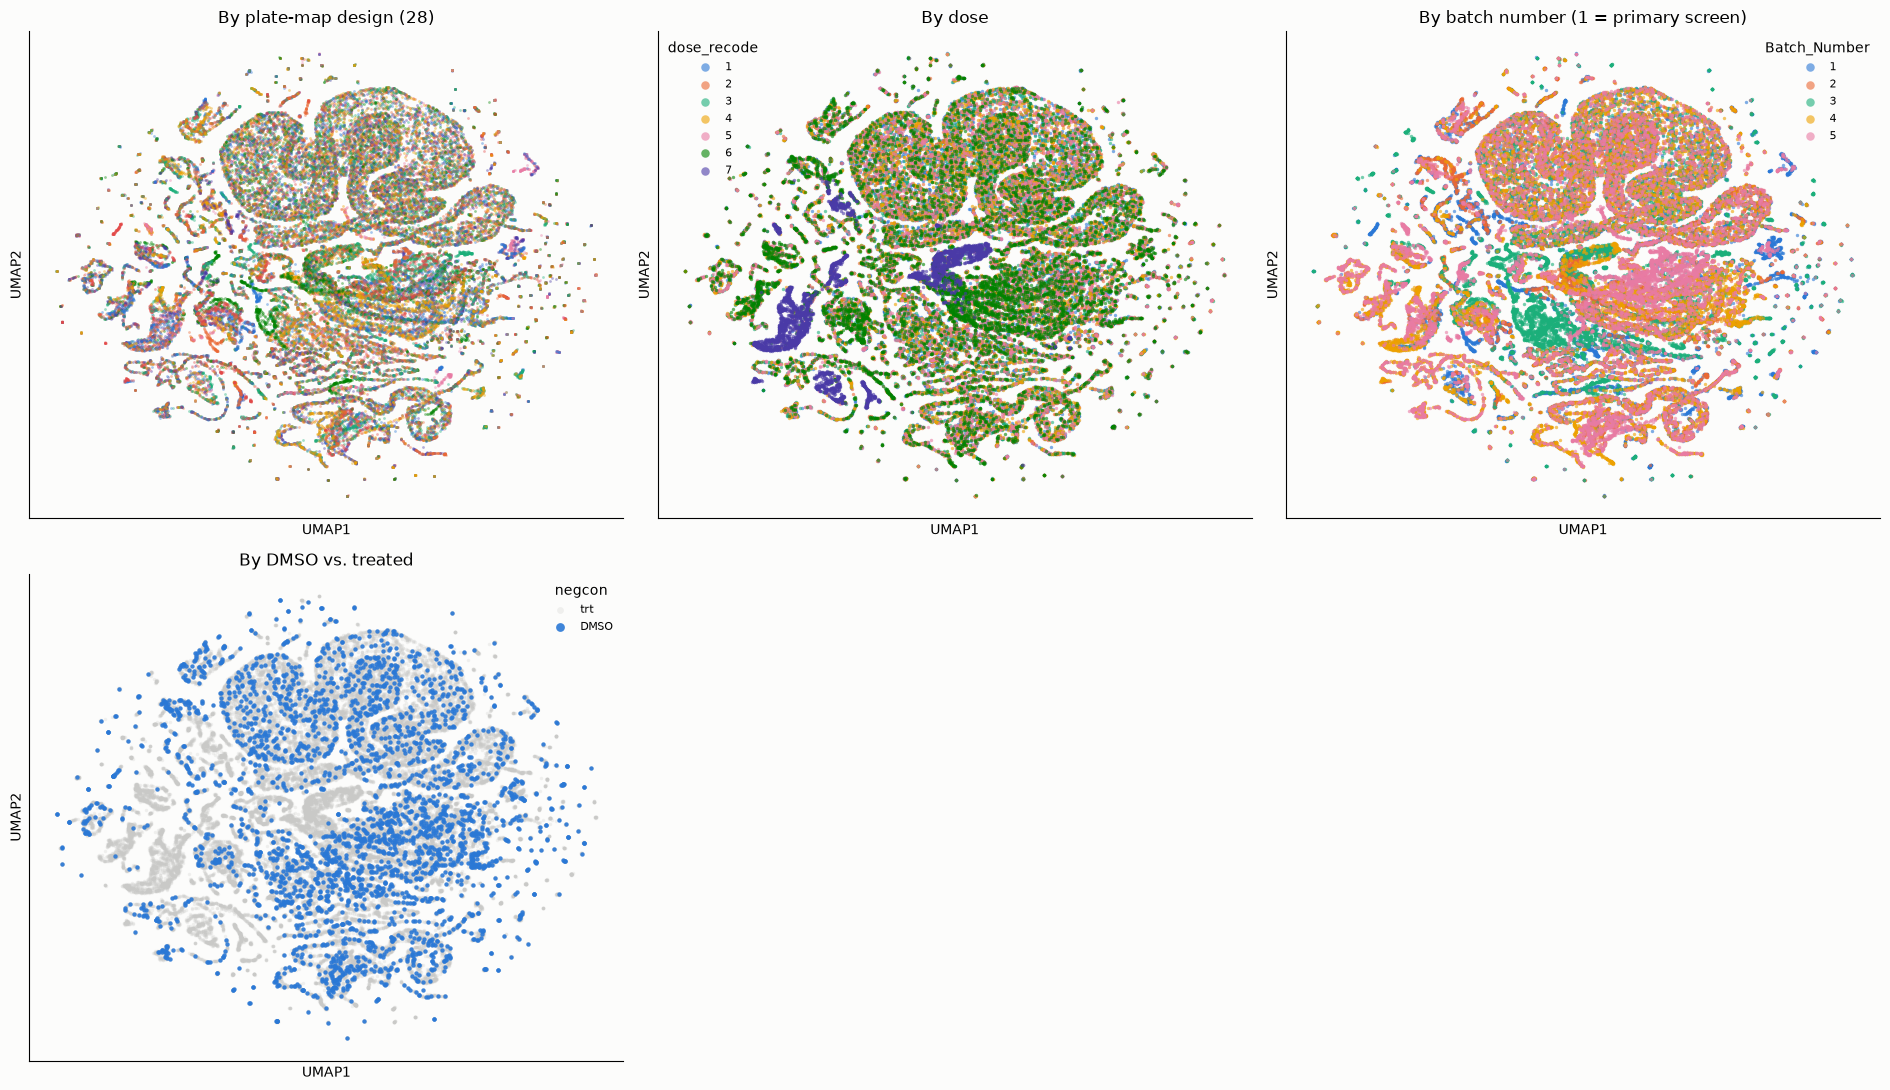

In [6]:
combined_umap = compute_umap(level4b_batch1, morph_feature_cols)

fig, axes = plt.subplots(2, 3, figsize=(19, 11))
plot_categorical_umap(axes[0, 0], combined_umap, "Metadata_Plate_Map_Name", "By plate-map design (28)", s=4, alpha=0.4)
plot_categorical_umap(axes[0, 1], combined_umap, "Metadata_dose_recode", "By dose")
plot_categorical_umap(axes[0, 2], combined_umap, "Metadata_Batch_Number", "By batch number (1 = primary screen)")
plot_negcon_umap(axes[1, 0], combined_umap, "By DMSO vs. treated")
axes[1, 1].axis("off")
axes[1, 2].axis("off")
fig.tight_layout()
plt.show()


## 6. How strong is the plate-map/dose/negcon structure?

Silhouette score of the combined PCA embedding using each label. As in
`morphology_umap_analysis.ipynb`, values near `+1` mean that label cleanly
separates clusters; near `0` or negative means it barely structures the
data.


In [7]:
pca_combined = combined_umap.obsm["X_pca"]
plate_map_labels = combined_umap.obs["Metadata_Plate_Map_Name"].to_numpy()
dose_labels = combined_umap.obs["Metadata_dose_recode"].to_numpy()
negcon_labels = combined_umap.obs["Metadata_negcon"].to_numpy()
batch_labels = combined_umap.obs["Metadata_Batch_Number"].to_numpy()

rng = np.random.RandomState(RANDOM_STATE)
n = pca_combined.shape[0]
sample_idx = rng.choice(n, size=min(n, 8000), replace=False)

plate_map_sil = silhouette_score(pca_combined[sample_idx], plate_map_labels[sample_idx])
dose_sil = silhouette_score(pca_combined[sample_idx], dose_labels[sample_idx])
negcon_sil = silhouette_score(pca_combined[sample_idx], negcon_labels[sample_idx])
batch_sil = silhouette_score(pca_combined[sample_idx], batch_labels[sample_idx])

print(f"Silhouette by Metadata_Plate_Map_Name : {plate_map_sil:.3f}")
print(f"Silhouette by Metadata_dose_recode     : {dose_sil:.3f}")
print(f"Silhouette by Metadata_negcon          : {negcon_sil:.3f}")
print(f"Silhouette by Metadata_Batch_Number    : {batch_sil:.3f}")


Silhouette by Metadata_Plate_Map_Name : -0.368
Silhouette by Metadata_dose_recode     : -0.032
Silhouette by Metadata_negcon          : -0.000
Silhouette by Metadata_Batch_Number    : 0.004


## 7. Does the primary screen (batch 1) reproduce in its confirmatory retest?

Batch 1 measures every plate-map design once; batches 2-5 each retest a
disjoint subset of ~7 designs at 3-4 replicate plates. For every
(`Metadata_broad_sample`, `Metadata_dose_recode`) combination that has
*both* a batch-1 well and at least one batch-2-5 well, correlate batch 1's
single measurement against the mean of its later replicate(s) - the direct,
apples-to-apples technical-reproducibility check this design supports, in
place of HepG2's site-vs-site comparison.


In [8]:
non_dmso = level4b_batch1[level4b_batch1["Metadata_broad_sample"] != "DMSO"]

batch1_wells = non_dmso[non_dmso["Metadata_Batch_Number"] == 1].set_index(["Metadata_broad_sample", "Metadata_dose_recode"])
later_wells = non_dmso[non_dmso["Metadata_Batch_Number"] != 1]
later_mean = later_wells.groupby(["Metadata_broad_sample", "Metadata_dose_recode"])[morph_feature_cols].mean()

shared_idx = batch1_wells.index.intersection(later_mean.index)
print(f"{len(shared_idx)} compound-dose combinations have both a batch-1 well and a later-batch replicate mean")

b1 = batch1_wells.loc[shared_idx, morph_feature_cols].to_numpy(dtype=np.float64)
later = later_mean.loc[shared_idx, morph_feature_cols].to_numpy(dtype=np.float64)
pair_corrs = np.array([np.corrcoef(b1[i], later[i])[0, 1] for i in range(len(shared_idx))])

print(f"batch1-vs-later-batches correlation: mean r={np.nanmean(pair_corrs):.3f}, "
      f"median r={np.nanmedian(pair_corrs):.3f} (n={len(pair_corrs)} compound-dose combinations)")


9393 compound-dose combinations have both a batch-1 well and a later-batch replicate mean


batch1-vs-later-batches correlation: mean r=0.023, median r=0.001 (n=9393 compound-dose combinations)


## 8. Does literature MoA structure survive?

Restricted to the top 8 MoA classes by well count (taking just the first
`|`-separated MoA label per compound, as elsewhere in this project), colored
on the same combined embedding, plus its silhouette score - the well-level
counterpart of the compound-level `moa-fine` silhouette checks in the two
integration notebooks, but here on the full batch1 library rather than only
the compounds shared with expression data.


Silhouette by top-8 Metadata_moa (DMSO/other-MoA wells excluded): -0.040


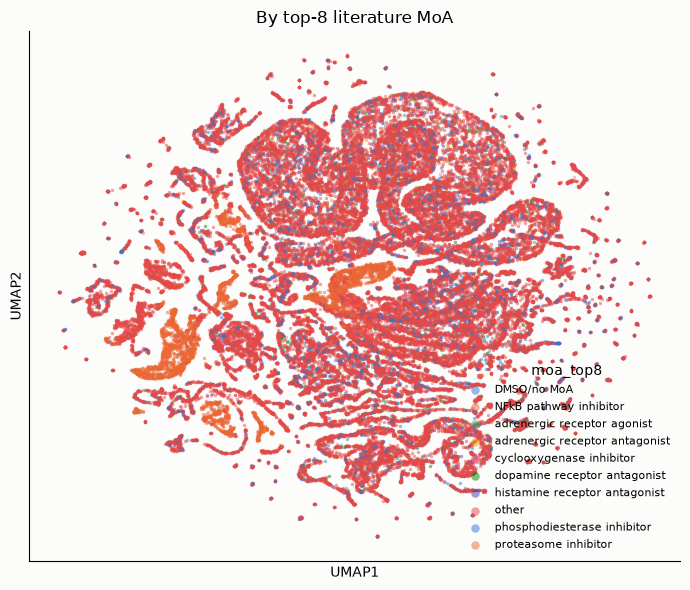

In [9]:
moa_first = level4b_batch1["Metadata_moa"].dropna().str.split("|").str[0]
top_moa = moa_first.value_counts().head(8).index
moa_label = moa_first.where(moa_first.isin(top_moa), "other").reindex(level4b_batch1.index)
moa_label = moa_label.fillna("DMSO/no MoA")
combined_umap.obs["Metadata_moa_top8"] = moa_label.astype(str).to_numpy()

moa_mask = combined_umap.obs["Metadata_moa_top8"] != "DMSO/no MoA"
moa_sil = silhouette_score(pca_combined[moa_mask.to_numpy()], combined_umap.obs.loc[moa_mask, "Metadata_moa_top8"])
print(f"Silhouette by top-8 Metadata_moa (DMSO/other-MoA wells excluded): {moa_sil:.3f}")

fig, ax = plt.subplots(figsize=(7, 6))
plot_categorical_umap(ax, combined_umap, "Metadata_moa_top8", "By top-8 literature MoA", s=6, alpha=0.5)
fig.tight_layout()
plt.show()


## 9. Summary

- **52,223 wells x 615 selected features** (Level 4b, one pooled feature
  selection across all 136 plates), 3,264 DMSO wells (6.3%).
- **None of the four structural/technical labels dominate the embedding**:
  silhouette by `Metadata_Plate_Map_Name` = -0.368, by `Metadata_dose_recode`
  = -0.032, by `Metadata_negcon` = -0.000, by `Metadata_Batch_Number` =
  0.004. All are at or below zero - directionally consistent with HepG2's
  own near-zero site/plate silhouettes in `morphology_umap_analysis.ipynb`
  (-0.005 / -0.090), just more strongly negative here. The plate-map design
  silhouette being the *most* negative of the four make sense once you
  remember what that label actually is: each design's 384 wells span ~58
  *different* compounds, so there's no reason wells sharing a design should
  resemble each other biologically - unlike HepG2's `PlateID`, where every
  plate ran the identical compound-dose content. A design isn't a compound
  fingerprint here, so it doesn't cluster like one.
- **Batch-1-vs-later-batches reproducibility is weak**: mean r=0.023, median
  r=0.001 across the 9,393 compound-dose combinations with both an early
  (batch 1) and a later, deeper-replicated (batch 2-5) measurement. This
  looks bad in isolation, but it's the *same* signal-to-noise story
  `lincs_morphology_expression_integration.ipynb` already found from a
  different angle: only 37.4% of compound-dose groups replicate above chance
  even when comparing same-batch replicate wells directly (median replicate
  r=0.003 there too), because most (compound, dose) pairs in this
  ~1500-compound, up-to-7-dose sparse screen just don't produce a
  detectable phenotype. A near-zero median correlation is the expected
  floor when the vast majority of pairs being correlated carry no real
  signal in either measurement - it says the assay's overall hit rate is
  low, not that measurements don't reproduce when there *is* a phenotype
  (which the sibling notebook's percent-replicating and mAP checks, run on
  actually-active compound-dose groups, already confirm separately).
- **Literature MoA doesn't separate at the raw well level either**
  (silhouette = -0.040 on the top-8 MoA classes by well count, DMSO/other-MoA
  wells excluded) - consistent with the negative `moa-fine` silhouettes
  found at the compound level in both integration notebooks. Coarse MoA
  labels don't correspond to tight morphological clusters in this screen,
  at any level of aggregation.
- **Net takeaway**: batch1's Cell Painting data shows no dominant technical
  batch/plate-design artifact (every structural silhouette is at or below
  zero), but also no strong recoverable biological signal at the raw,
  unaggregated well level - both findings are consistent with, and
  reinforce, what `lincs_morphology_expression_integration.ipynb` already
  established via percent-replicating, mAP, and consensus-level analysis:
  this is a sparse, mostly-sub-effective-dose screen where a minority of
  (compound, dose) pairs carry real signal, and it takes aggregating to the
  consensus/compound level (as that notebook does) to see it clearly.


In [10]:
print("See section 9's markdown for the narrative summary of the numbers computed above.")


See section 9's markdown for the narrative summary of the numbers computed above.
